# Alzheimer's Disease — Recommendation System
**Machine Learning Project — MindCare**

---

### Pipeline
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training — RF Baseline + Gradient Boosting
5. Feature Importance
6. Model Evaluation — Cross-Validation, ROC Curve, Confusion Matrix
7. Benchmarking — RF vs GB
8. Recommendation Demo
9. Hyperparameter Optimisation — Optuna (TPE, 50 trials)
10. Explainability — SHAP TreeExplainer

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Loading & Overview

In [4]:
DATA_PATH = os.path.join('..', 'data', 'alzheimers_disease_data.csv')
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape : {df.shape}')
print(f'Patients      : {df.shape[0]}')
print(f'Columns       : {df.shape[1]}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates    : {df.duplicated().sum()}')
df.head()

Dataset shape : (2149, 35)
Patients      : 2149
Columns       : 35
Missing values: 0
Duplicates    : 0


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [5]:
print('=== Target Variable ===')
print(df['Diagnosis'].value_counts().rename({0: 'Healthy (0)', 1: "Alzheimer's (1)"}))
print(f'\nClass ratio: {df["Diagnosis"].value_counts(normalize=True).round(3).to_dict()}')

=== Target Variable ===
Diagnosis
Healthy (0)        1389
Alzheimer's (1)     760
Name: count, dtype: int64

Class ratio: {0: 0.646, 1: 0.354}


In [6]:
FEATURE_COLS = [
    'Age', 'Gender', 'Ethnicity', 'EducationLevel',
    'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
    'Depression', 'HeadInjury', 'Hypertension',
    'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL',
    'CholesterolHDL', 'CholesterolTriglycerides',
    'MMSE', 'FunctionalAssessment', 'MemoryComplaints',
    'BehavioralProblems', 'ADL',
    'Confusion', 'Disorientation', 'PersonalityChanges',
    'DifficultyCompletingTasks', 'Forgetfulness',
]

print(f'Total features used: {len(FEATURE_COLS)}')
print(df[FEATURE_COLS].describe().round(2))

Total features used: 32
           Age   Gender  Ethnicity  EducationLevel      BMI  Smoking  \
count  2149.00  2149.00     2149.0         2149.00  2149.00  2149.00   
mean     74.91     0.51        0.7            1.29    27.66     0.29   
std       8.99     0.50        1.0            0.90     7.22     0.45   
min      60.00     0.00        0.0            0.00    15.01     0.00   
25%      67.00     0.00        0.0            1.00    21.61     0.00   
50%      75.00     1.00        0.0            1.00    27.82     0.00   
75%      83.00     1.00        1.0            2.00    33.87     1.00   
max      90.00     1.00        3.0            3.00    39.99     1.00   

       AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
count             2149.00           2149.00      2149.00       2149.00  ...   
mean                10.04              4.92         4.99          7.05  ...   
std                  5.76              2.86         2.91          1.76  ...   
min        

---
## 2. Exploratory Data Analysis (EDA)

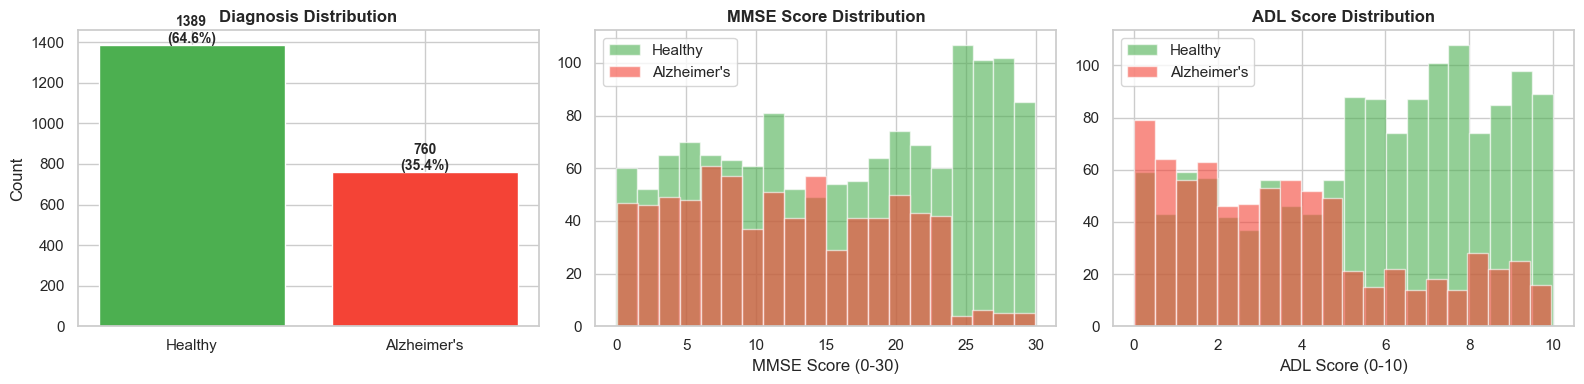

In [7]:
# Diagnosis distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df['Diagnosis'].value_counts()
axes[0].bar(["Healthy", "Alzheimer's"], counts.values, color=['#4CAF50', '#F44336'], edgecolor='white')
axes[0].set_title('Diagnosis Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)

# MMSE by diagnosis
df[df['Diagnosis']==0]['MMSE'].hist(ax=axes[1], alpha=0.6, color='#4CAF50', label='Healthy', bins=20)
df[df['Diagnosis']==1]['MMSE'].hist(ax=axes[1], alpha=0.6, color='#F44336', label="Alzheimer's", bins=20)
axes[1].set_title('MMSE Score Distribution', fontweight='bold')
axes[1].set_xlabel('MMSE Score (0-30)')
axes[1].legend()

# ADL by diagnosis
df[df['Diagnosis']==0]['ADL'].hist(ax=axes[2], alpha=0.6, color='#4CAF50', label='Healthy', bins=20)
df[df['Diagnosis']==1]['ADL'].hist(ax=axes[2], alpha=0.6, color='#F44336', label="Alzheimer's", bins=20)
axes[2].set_title('ADL Score Distribution', fontweight='bold')
axes[2].set_xlabel('ADL Score (0-10)')
axes[2].legend()

plt.tight_layout()
plt.show()

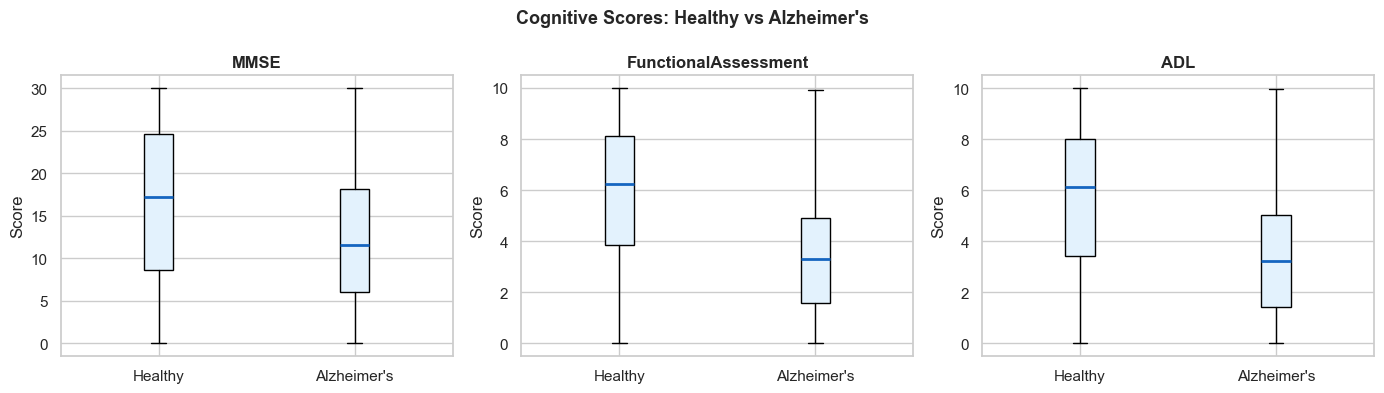

In [8]:
# Cognitive features comparison
cognitive = ['MMSE', 'FunctionalAssessment', 'ADL']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(cognitive):
    data_healthy = df[df['Diagnosis']==0][col]
    data_alz     = df[df['Diagnosis']==1][col]
    axes[i].boxplot([data_healthy, data_alz], labels=['Healthy', "Alzheimer's"],
                    patch_artist=True,
                    boxprops=dict(facecolor='#e3f2fd'),
                    medianprops=dict(color='#1565c0', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Score')

plt.suptitle('Cognitive Scores: Healthy vs Alzheimer\'s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

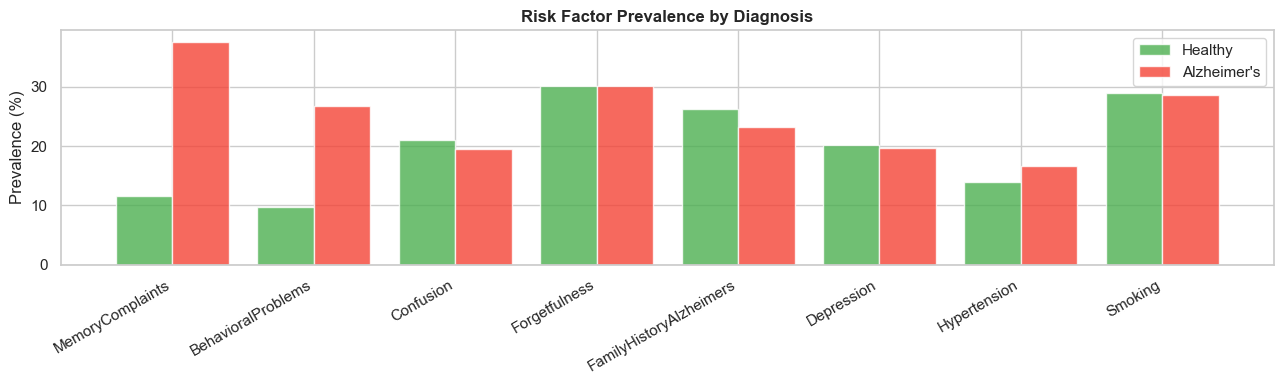

In [9]:
# Binary risk factors prevalence
binary_cols = [
    'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Forgetfulness',
    'FamilyHistoryAlzheimers', 'Depression', 'Hypertension', 'Smoking'
]

prev_healthy = df[df['Diagnosis']==0][binary_cols].mean() * 100
prev_alz     = df[df['Diagnosis']==1][binary_cols].mean() * 100

x = np.arange(len(binary_cols))
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - 0.2, prev_healthy, 0.4, label='Healthy', color='#4CAF50', alpha=0.8)
ax.bar(x + 0.2, prev_alz,     0.4, label="Alzheimer's", color='#F44336', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(binary_cols, rotation=30, ha='right')
ax.set_ylabel('Prevalence (%)')
ax.set_title('Risk Factor Prevalence by Diagnosis', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

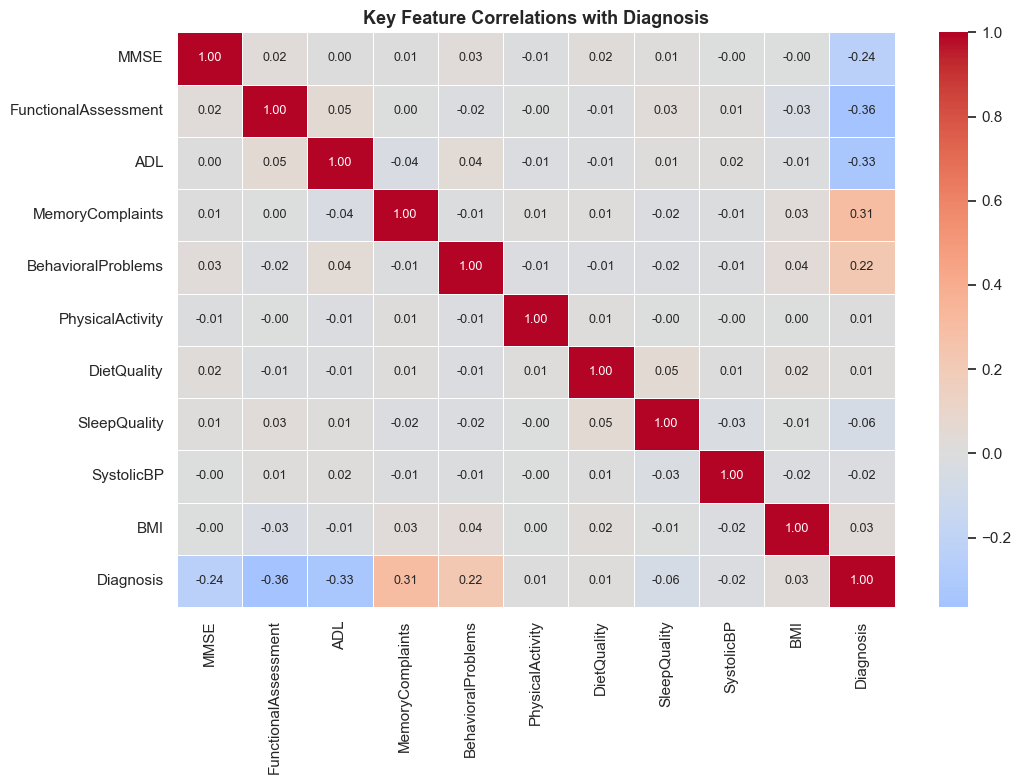

Top features correlated with Diagnosis:
FunctionalAssessment    0.365
ADL                     0.332
MemoryComplaints        0.307
MMSE                    0.237
BehavioralProblems      0.224
SleepQuality            0.057
BMI                     0.026
SystolicBP              0.016
Name: Diagnosis, dtype: float64


In [10]:
# Correlation heatmap — key features
key_feats = ['MMSE', 'FunctionalAssessment', 'ADL', 'MemoryComplaints',
             'BehavioralProblems', 'PhysicalActivity', 'DietQuality',
             'SleepQuality', 'SystolicBP', 'BMI', 'Diagnosis']

plt.figure(figsize=(11, 8))
corr = df[key_feats].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Key Feature Correlations with Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features correlated with Diagnosis:')
print(corr['Diagnosis'].drop('Diagnosis').abs().sort_values(ascending=False).head(8).round(3))

---
## 3. Preprocessing
- **StandardScaler**: normalize all features to mean=0, std=1
- **Healthy baseline**: compute mean & std from non-diagnosed patients only (used for recommendation contribution scoring)

In [11]:
X = df[FEATURE_COLS].values
y = df['Diagnosis'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix : {X_scaled.shape}')
print(f'Mean (scaled)  : {X_scaled.mean():.6f}  (expected ~0)')
print(f'Std  (scaled)  : {X_scaled.std():.6f}  (expected ~1)')
print(f'Class balance  : {np.bincount(y)} (healthy / alzheimers)')

Feature matrix : (2149, 32)
Mean (scaled)  : -0.000000  (expected ~0)
Std  (scaled)  : 1.000000  (expected ~1)
Class balance  : [1389  760] (healthy / alzheimers)


In [12]:
# Healthy baseline — computed from non-diagnosed patients only
healthy_df   = df[df['Diagnosis'] == 0][FEATURE_COLS]
healthy_mean = healthy_df.mean()
healthy_std  = healthy_df.std()

print(f'Healthy baseline computed from {len(healthy_df)} non-diagnosed patients')
print('\nHealthy averages (top cognitive/lifestyle features):')
key_show = ['MMSE', 'FunctionalAssessment', 'ADL', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'BMI', 'SystolicBP']
pd.DataFrame({'Healthy Mean': healthy_mean[key_show].round(2), 'Healthy Std': healthy_std[key_show].round(2)})

Healthy baseline computed from 1389 non-diagnosed patients

Healthy averages (top cognitive/lifestyle features):


,Healthy Mean,Healthy Std
MMSE,16.27,8.93
FunctionalAssessment,5.86,2.76
ADL,5.71,2.83
PhysicalActivity,4.91,2.87
DietQuality,4.97,2.91
SleepQuality,7.12,1.76
BMI,27.52,7.17
SystolicBP,134.56,25.95


---
## 4. Model Training — Random Forest + Gradient Boosting

**Why these two models?**
- Both are state-of-the-art for tabular/clinical data
- Both provide **feature importance** (essential for ranking recommendations)
- They are complementary: RF reduces variance, GB reduces bias
- Averaging their probabilities (ensemble) gives a more stable prediction

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest (5-fold CV)...')
rf_auc = cross_val_score(rf, X_scaled, y, cv=cv, scoring='roc_auc')
rf_acc = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
print(f'  AUC  : {rf_auc.mean():.4f} +/- {rf_auc.std():.4f}')
print(f'  Acc  : {rf_acc.mean():.4f} +/- {rf_acc.std():.4f}')
rf.fit(X_scaled, y)
print('  Done.')

Training Random Forest (5-fold CV)...
  AUC  : 0.9524 +/- 0.0068
  Acc  : 0.9493 +/- 0.0060
  Done.


In [15]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

print('Training Gradient Boosting (5-fold CV)...')
gb_auc = cross_val_score(gb, X_scaled, y, cv=cv, scoring='roc_auc')
gb_acc = cross_val_score(gb, X_scaled, y, cv=cv, scoring='accuracy')
print(f'  AUC  : {gb_auc.mean():.4f} +/- {gb_auc.std():.4f}')
print(f'  Acc  : {gb_acc.mean():.4f} +/- {gb_acc.std():.4f}')
gb.fit(X_scaled, y)
print('  Done.')

Training Gradient Boosting (5-fold CV)...
  AUC  : 0.9487 +/- 0.0108
  Acc  : 0.9525 +/- 0.0043
  Done.


In [16]:
# Winner selection: pick the model with highest CV AUC
if rf_auc.mean() >= gb_auc.mean():
    best_model = rf
    best_name  = 'Random Forest'
    best_short = 'rf'
    best_auc   = rf_auc.mean()
else:
    best_model = gb
    best_name  = 'Gradient Boosting'
    best_short = 'gb'
    best_auc   = gb_auc.mean()

y_prob_best = best_model.predict_proba(X_scaled)[:, 1]
y_pred_best = (y_prob_best >= 0.5).astype(int)

print(f'=== Winner Model: {best_name} ===')
print(f'CV AUC   : {best_auc:.4f}')
print(f'Train AUC: {roc_auc_score(y, y_prob_best):.4f}')
print(f'Accuracy : {accuracy_score(y, y_pred_best):.4f}')
print()
print(classification_report(y, y_pred_best, target_names=["Healthy", "Alzheimer's"]))

=== Winner Model: Random Forest ===
CV AUC   : 0.9524
Train AUC: 0.9863
Accuracy : 0.9595

              precision    recall  f1-score   support

     Healthy       0.96      0.98      0.97      1389
 Alzheimer's       0.95      0.93      0.94       760

    accuracy                           0.96      2149
   macro avg       0.96      0.95      0.96      2149
weighted avg       0.96      0.96      0.96      2149



---
## 5. Feature Importance

In [17]:
rf_imp  = pd.Series(rf.feature_importances_,  index=FEATURE_COLS)
gb_imp  = pd.Series(gb.feature_importances_,  index=FEATURE_COLS)
avg_imp = ((rf_imp + gb_imp) / 2).sort_values(ascending=False)

# Winner model importance (used in later sections)
best_imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

print(f'Top 10 features (winner model — {best_name}):')
for feat, imp in best_imp.head(10).items():
    print(f'  {feat:<30} {imp:.4f}')

Top 10 features (winner model — Random Forest):
  FunctionalAssessment           0.2438
  ADL                            0.2137
  MMSE                           0.1616
  MemoryComplaints               0.1054
  BehavioralProblems             0.0631
  SleepQuality                   0.0195
  CholesterolHDL                 0.0185
  DietQuality                    0.0173
  CholesterolLDL                 0.0165
  BMI                            0.0164


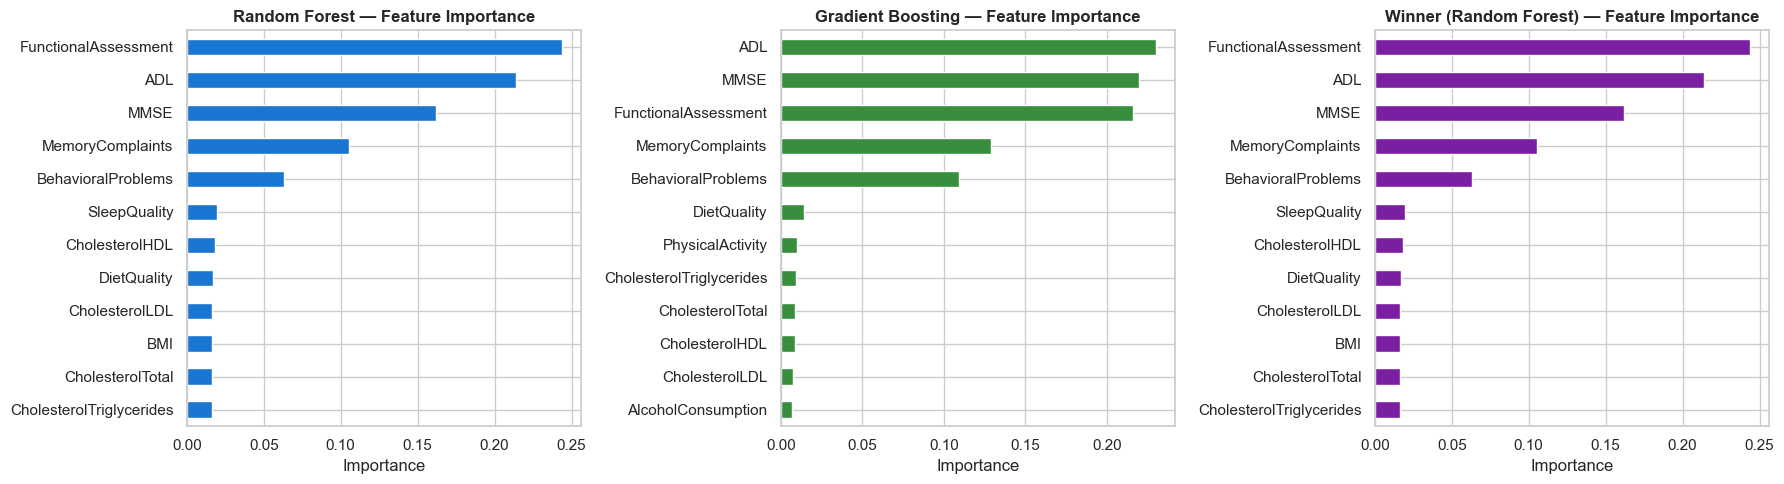

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rf_imp.sort_values().tail(12).plot(kind='barh', ax=axes[0], color='#1976D2')
axes[0].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance')

gb_imp.sort_values().tail(12).plot(kind='barh', ax=axes[1], color='#388E3C')
axes[1].set_title('Gradient Boosting — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

best_imp.sort_values().tail(12).plot(kind='barh', ax=axes[2], color='#7B1FA2')
axes[2].set_title(f'Winner ({best_name}) — Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

---
## 6. Model Evaluation — ROC Curve & Confusion Matrix

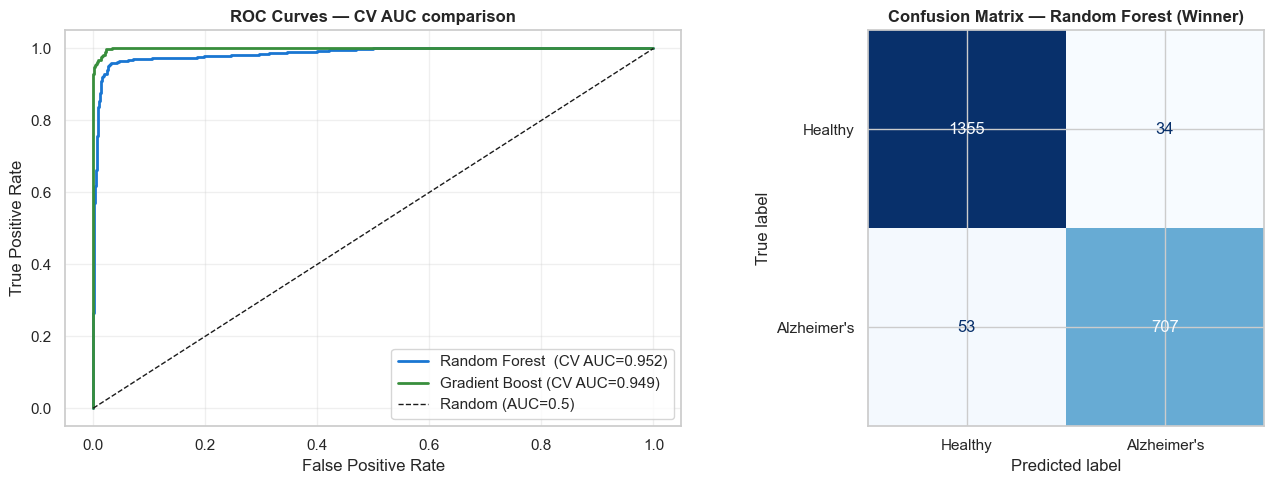

In [19]:
# ROC Curves — use honest CV AUC in labels (not inflated train AUC)
# Train AUC is ~0.99 because the model has already seen this data.
# CV AUC is the reliable generalisation estimate.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for probs, label, color in [
    (rf.predict_proba(X_scaled)[:, 1],
     f'Random Forest  (CV AUC={rf_auc.mean():.3f})',  '#1976D2'),
    (gb.predict_proba(X_scaled)[:, 1],
     f'Gradient Boost (CV AUC={gb_auc.mean():.3f})', '#388E3C'),
]:
    fpr, tpr, _ = roc_curve(y, probs)
    axes[0].plot(fpr, tpr, label=label, linewidth=2, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — CV AUC comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion Matrix — Winner
cm = confusion_matrix(y, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Alzheimer's"])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_name} (Winner)', fontweight='bold')

plt.tight_layout()
plt.show()

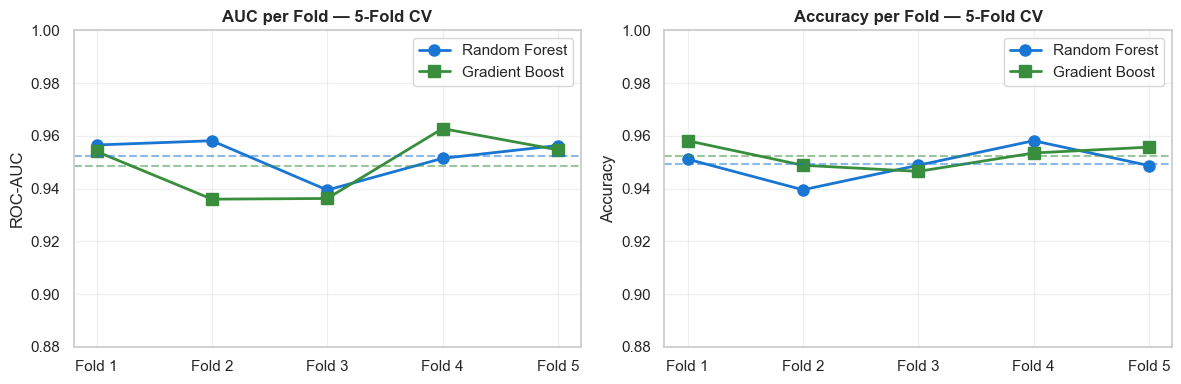

In [20]:
# Cross-validation scores per fold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)

axes[0].plot(folds, rf_auc, 'o-', color='#1976D2', linewidth=2, markersize=8, label='Random Forest')
axes[0].plot(folds, gb_auc, 's-', color='#388E3C', linewidth=2, markersize=8, label='Gradient Boost')
axes[0].axhline(rf_auc.mean(), color='#1976D2', linestyle='--', alpha=0.5)
axes[0].axhline(gb_auc.mean(), color='#388E3C', linestyle='--', alpha=0.5)
axes[0].set_title('AUC per Fold — 5-Fold CV', fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_ylim([0.88, 1.0])
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(folds, rf_acc, 'o-', color='#1976D2', linewidth=2, markersize=8, label='Random Forest')
axes[1].plot(folds, gb_acc, 's-', color='#388E3C', linewidth=2, markersize=8, label='Gradient Boost')
axes[1].axhline(rf_acc.mean(), color='#1976D2', linestyle='--', alpha=0.5)
axes[1].axhline(gb_acc.mean(), color='#388E3C', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy per Fold — 5-Fold CV', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.88, 1.0])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Benchmarking — RF vs GB

In [23]:
y_prob_rf = rf.predict_proba(X_scaled)[:, 1]
y_prob_gb = gb.predict_proba(X_scaled)[:, 1]

benchmarking = pd.DataFrame({
    'Metric'            : ['CV AUC (mean)', 'CV AUC (std)', 'CV Accuracy', 'Train AUC', 'Train Accuracy'],
    'Random Forest'     : [
        round(rf_auc.mean(), 4),
        round(rf_auc.std(),  4),
        round(rf_acc.mean(), 4),
        round(roc_auc_score(y, y_prob_rf), 4),
        round(accuracy_score(y, rf.predict(X_scaled)), 4),
    ],
    'Gradient Boosting' : [
        round(gb_auc.mean(), 4),
        round(gb_auc.std(),  4),
        round(gb_acc.mean(), 4),
        round(roc_auc_score(y, y_prob_gb), 4),
        round(accuracy_score(y, gb.predict(X_scaled)), 4),
    ],
})

print('=== Benchmarking Table ===')
print(f'Winner: {best_name}  (selected by CV AUC)')
benchmarking

=== Benchmarking Table ===
Winner: Random Forest  (selected by CV AUC)


,Metric,Random Forest,Gradient Boosting
0,CV AUC (mean),0.9524,0.9487
1,CV AUC (std),0.0068,0.0108
2,CV Accuracy,0.9493,0.9525
3,Train AUC,0.9863,0.9992
4,Train Accuracy,0.9595,0.9805


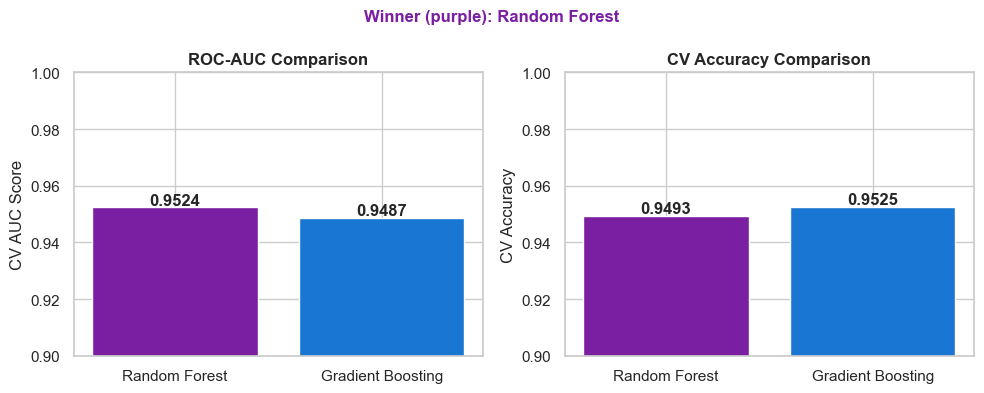

In [24]:
# Visual benchmarking — highlight the winner
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models = ['Random Forest', 'Gradient Boosting']
aucs   = [rf_auc.mean(), gb_auc.mean()]
accs   = [rf_acc.mean(), gb_acc.mean()]
colors = ['#1976D2' if m != best_name else '#7B1FA2' for m in models]

bars1 = axes[0].bar(models, aucs, color=colors, edgecolor='white')
axes[0].set_title('ROC-AUC Comparison', fontweight='bold')
axes[0].set_ylabel('CV AUC Score')
axes[0].set_ylim([0.9, 1.0])
for bar, val in zip(bars1, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha='center', fontweight='bold')

bars2 = axes[1].bar(models, accs, color=colors, edgecolor='white')
axes[1].set_title('CV Accuracy Comparison', fontweight='bold')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_ylim([0.9, 1.0])
for bar, val in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha='center', fontweight='bold')

plt.suptitle(f'Winner (purple): {best_name}', fontsize=12, fontweight='bold', color='#7B1FA2')
plt.tight_layout()
plt.show()

In [25]:
# Forces / Faiblesses
summary = pd.DataFrame({
    'Criterion'          : ['Training', 'Overfitting risk', 'Stability (CV std)', 'Interpretability', 'Best use case'],
    'Random Forest'      : ['Fast (parallel trees)', 'Low', f'{rf_auc.std():.4f} (more stable)', 'Feature importance', 'Robust baseline'],
    'Gradient Boosting'  : ['Slower (sequential)', 'Medium', f'{gb_auc.std():.4f}', 'Feature importance', 'Complex patterns'],
})
print('=== Forces / Faiblesses ===')
summary

=== Forces / Faiblesses ===


,Criterion,Random Forest,Gradient Boosting
0,Training,Fast (parallel trees),Slower (sequential)
1,Overfitting risk,Low,Medium
2,Stability (CV std),0.0068 (more stable),0.0108
3,Interpretability,Feature importance,Feature importance
4,Best use case,Robust baseline,Complex patterns


---
## 8. Recommendation Demo

How recommendations are generated:
1. Patient features → StandardScaler
2. RF + GB → ensemble risk score (0–100)
3. Per-feature contribution = `feature_importance × deviation_from_healthy_mean / std`
4. Top contributors → High/Medium/Low priority
5. Template filled with patient's actual value

In [26]:
import sys
sys.path.insert(0, '..')
from model.recommender import recommend

# High-risk patient
patient_high = {
    'Age': 75, 'Gender': 1, 'Ethnicity': 0, 'EducationLevel': 1,
    'BMI': 29.5, 'Smoking': 1, 'AlcoholConsumption': 10,
    'PhysicalActivity': 1.2, 'DietQuality': 3.0, 'SleepQuality': 5.0,
    'FamilyHistoryAlzheimers': 1, 'CardiovascularDisease': 1, 'Diabetes': 0,
    'Depression': 1, 'HeadInjury': 0, 'Hypertension': 1,
    'SystolicBP': 145, 'DiastolicBP': 90, 'CholesterolTotal': 240,
    'CholesterolLDL': 160, 'CholesterolHDL': 35, 'CholesterolTriglycerides': 220,
    'MMSE': 20, 'FunctionalAssessment': 4, 'MemoryComplaints': 1,
    'BehavioralProblems': 1, 'ADL': 4,
    'Confusion': 1, 'Disorientation': 1, 'PersonalityChanges': 1,
    'DifficultyCompletingTasks': 1, 'Forgetfulness': 1
}

result = recommend(patient_high)

print(f'Risk Score  : {result["risk_score"]} / 100')
print(f'Risk Label  : {result["risk_label"]}')
print(f'Model Prob  : {result["model_prob"]}%   (winner: {result["model_info"]["model"]})')
print(f'CV AUC      : {result["model_info"]["cv_auc"]}')
print(f'Total Recs  : {result["total_recommendations"]}')
print()
print('Top 3 Risk Drivers:')
for d in result['risk_drivers']:
    print(f'  {d["feature"]:<25} contribution={d["contribution"]:.4f}  '
          f'patient={d["patient_value"]}  healthy_avg={d["healthy_avg"]}')

Risk Score  : 100.0 / 100
Risk Label  : High Risk
Model Prob  : 85.2%   (winner: RF)
CV AUC      : 0.9525
Total Recs  : 19

Top 3 Risk Drivers:
  FunctionalAssessment      contribution=0.1803  patient=4  healthy_avg=5.86
  ADL                       contribution=0.1400  patient=4  healthy_avg=5.71
  MemoryComplaints          contribution=0.1153  patient=1  healthy_avg=0.12


In [27]:
recs_df = pd.DataFrame(result['recommendations'])[
    ['priority', 'category', 'recommendation', 'contribution_score', 'patient_value', 'healthy_avg', 'detail']
].round({'contribution_score': 4, 'healthy_avg': 2})

def color_priority(val):
    colors = {'High': 'background-color:#ffcccc', 'Medium': 'background-color:#fff3cc', 'Low': 'background-color:#ccffcc'}
    return colors.get(val, '')

recs_df.style.map(color_priority, subset=['priority'])

,priority,category,recommendation,contribution_score,patient_value,healthy_avg,detail
0,High,Cognitive,Functional Rehabilitation,0.180300,4.000000,5.860000,Functional assessment 4.0/10 (healthy avg: 5.9). Physiotherapy and structured daily routine recommended.
1,High,Cognitive,Daily Living Support,0.140000,4.000000,5.710000,ADL 4.0/10 (healthy avg: 5.7). Occupational therapy and in-home care assessment recommended.
2,High,Cognitive,Memory Clinic Referral,0.115300,1.000000,0.120000,Subjective memory complaints warrant comprehensive neuropsychological assessment to distinguish normal aging from MCI.
3,High,Mental Health,Behavioral Management,0.060100,1.000000,0.100000,"Behavioral symptoms can be managed through structured routines, music therapy, and caregiver training."
4,High,Lifestyle,Sleep Quality Improvement,0.019000,5.000000,7.120000,Sleep quality 5.0/10 (healthy avg: 7.1/10). Poor sleep is linked to amyloid buildup. Evaluate for sleep apnea.
5,Medium,Lifestyle,Increase Physical Activity,0.015800,1.200000,4.910000,1.2h/week recorded (healthy avg: 4.9h/week). Aim for at least 2.5h/week of moderate aerobic exercise.
6,Medium,Clinical,Increase HDL Cholesterol,0.013400,35.000000,58.730000,HDL 35 mg/dL (healthy avg: 59). Aerobic exercise and omega-3 supplementation recommended.
7,Medium,Clinical,LDL Cholesterol Management,0.010800,160.000000,125.360000,LDL 160 mg/dL (healthy avg: 125). Dietary changes and possible statin therapy recommended.
8,Medium,Lifestyle,Dietary Improvement,0.008800,3.000000,4.970000,Diet quality 3.0/10 (healthy avg: 5.0/10). Mediterranean diet recommended — shown to slow cognitive decline.
9,Medium,Clinical,Blood Pressure Management,0.004200,145.000000,134.560000,BP 145/90 mmHg (healthy avg: 135/90). Hypertension is a major modifiable dementia risk factor.


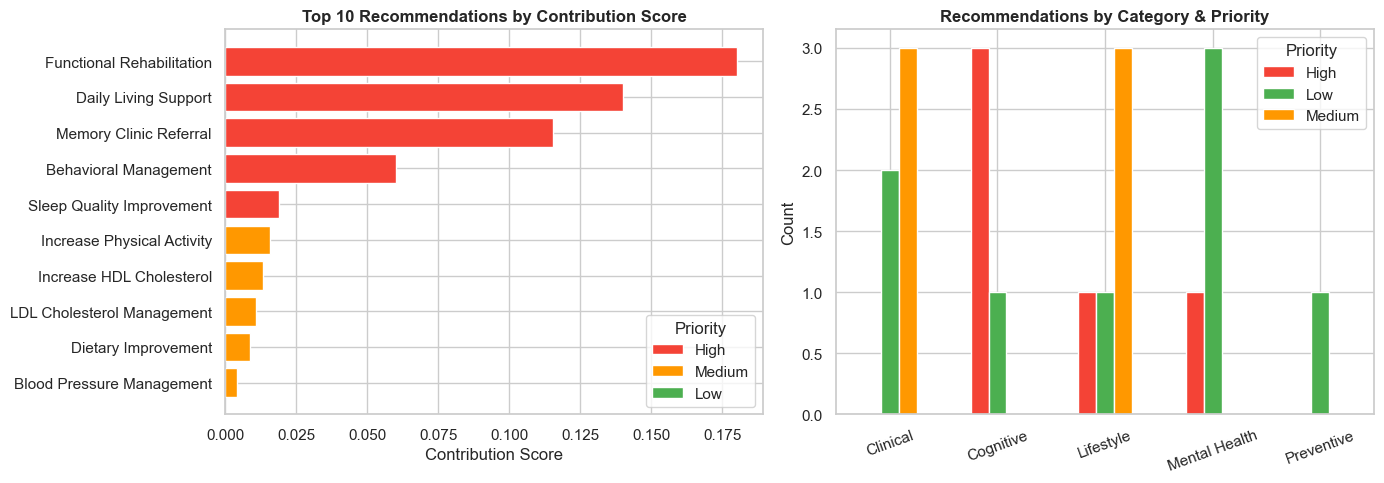

In [28]:
# Recommendations: contribution score chart
recs_plot = pd.DataFrame(result['recommendations']).head(10)
colors_map = {'High': '#F44336', 'Medium': '#FF9800', 'Low': '#4CAF50'}
bar_colors = [colors_map[p] for p in recs_plot['priority']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(recs_plot['recommendation'], recs_plot['contribution_score'], color=bar_colors)
axes[0].set_xlabel('Contribution Score')
axes[0].set_title('Top 10 Recommendations by Contribution Score', fontweight='bold')
axes[0].invert_yaxis()
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F44336', label='High'), Patch(facecolor='#FF9800', label='Medium'), Patch(facecolor='#4CAF50', label='Low')]
axes[0].legend(handles=legend_elements, title='Priority')

# By category
cat_counts = pd.DataFrame(result['recommendations']).groupby(['category', 'priority']).size().unstack(fill_value=0)
cat_counts.plot(kind='bar', ax=axes[1], color=['#F44336', '#4CAF50', '#FF9800'], edgecolor='white')
axes[1].set_title('Recommendations by Category & Priority', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Priority')

plt.tight_layout()
plt.show()

In [29]:
# Compare low-risk vs high-risk patient
patient_low = {
    'Age': 65, 'Gender': 0, 'Ethnicity': 0, 'EducationLevel': 3,
    'BMI': 22.0, 'Smoking': 0, 'AlcoholConsumption': 2,
    'PhysicalActivity': 6.0, 'DietQuality': 8.5, 'SleepQuality': 8.5,
    'FamilyHistoryAlzheimers': 0, 'CardiovascularDisease': 0, 'Diabetes': 0,
    'Depression': 0, 'HeadInjury': 0, 'Hypertension': 0,
    'SystolicBP': 110, 'DiastolicBP': 70, 'CholesterolTotal': 160,
    'CholesterolLDL': 80, 'CholesterolHDL': 75, 'CholesterolTriglycerides': 100,
    'MMSE': 29, 'FunctionalAssessment': 9, 'MemoryComplaints': 0,
    'BehavioralProblems': 0, 'ADL': 9.5,
    'Confusion': 0, 'Disorientation': 0, 'PersonalityChanges': 0,
    'DifficultyCompletingTasks': 0, 'Forgetfulness': 0
}

result_low = recommend(patient_low)

comparison = pd.DataFrame({
    'Metric'           : ['Risk Score', 'Risk Label', 'Model Probability', 'Winner Model', 'Total Recommendations'],
    'Healthy Patient'  : [
        result_low['risk_score'], result_low['risk_label'],
        f"{result_low['model_prob']}%", result_low['model_info']['model'],
        result_low['total_recommendations'],
    ],
    'High-Risk Patient': [
        result['risk_score'], result['risk_label'],
        f"{result['model_prob']}%", result['model_info']['model'],
        result['total_recommendations'],
    ],
})

print('=== Patient Comparison ===')
comparison

=== Patient Comparison ===


,Metric,Healthy Patient,High-Risk Patient
0,Risk Score,12.3,100.0
1,Risk Label,Low Risk,High Risk
2,Model Probability,12.3%,85.2%
3,Winner Model,RF,RF
4,Total Recommendations,0,19


---
## 9. Hyperparameter Optimisation — Optuna

**Why Optuna?**
- Grid search over 5 hyperparameters with reasonable ranges = thousands of combinations
- Optuna's **TPE (Tree-structured Parzen Estimator)** sampler learns from previous trials and focuses on promising regions — much more efficient than exhaustive search
- 50 trials typically find near-optimal parameters in a fraction of the time

**Search space**

| Parameter | Range |
|-----------|-------|
| `n_estimators` | 100 – 500 |
| `max_depth` | 4 – 20 |
| `min_samples_leaf` | 1 – 20 |
| `min_samples_split` | 2 – 20 |
| `max_features` | sqrt / log2 |

**Objective:** maximise 5-fold CV ROC-AUC

In [35]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 4, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':      'balanced',
        'random_state':      42,
        'n_jobs':            -1,
    }
    model  = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc')
    return scores.mean()

print('Running Optuna (50 trials, TPE sampler)...')
sampler = optuna.samplers.TPESampler(seed=42)
study   = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=False)

print(f'\nBest CV AUC : {study.best_value:.4f}')
print(f'Best params : {study.best_params}')

Running Optuna (50 trials, TPE sampler)...

Best CV AUC : 0.9525
Best params : {'n_estimators': 245, 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 4, 'max_features': 'log2'}


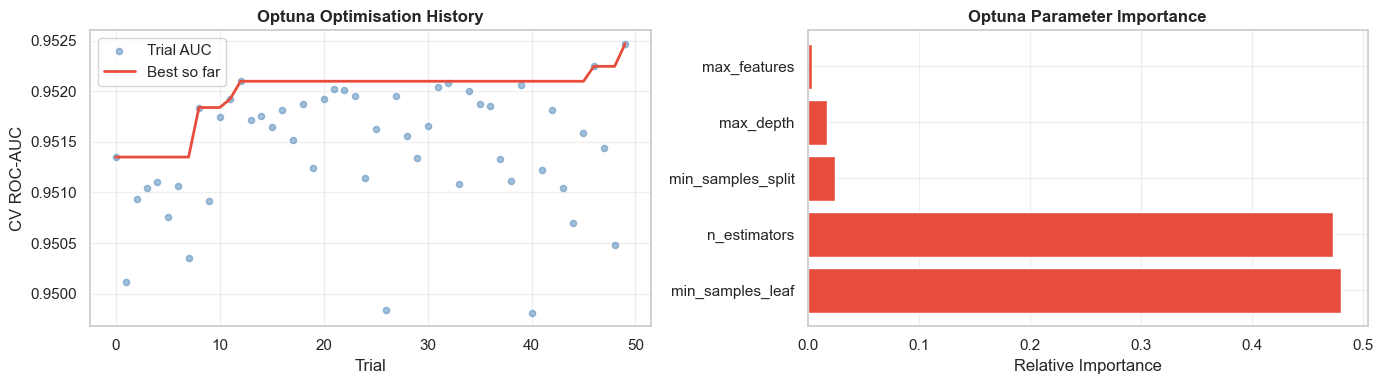

In [40]:
# Optuna optimisation history plot
trial_values = [t.value for t in study.trials]
best_so_far  = np.maximum.accumulate(trial_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(range(len(trial_values)), trial_values, alpha=0.5, s=20,
                color='steelblue', label='Trial AUC')
axes[0].plot(range(len(best_so_far)), best_so_far, color='#e74c3c',
             linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV ROC-AUC')
axes[0].set_title('Optuna Optimisation History', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Parameter importance
param_imp = optuna.importance.get_param_importances(study)
params_sorted = list(param_imp.keys())
values_sorted = [param_imp[k] for k in params_sorted]
axes[1].barh(params_sorted, values_sorted, color='#e74c3c')
axes[1].set_xlabel('Relative Importance')
axes[1].set_title('Optuna Parameter Importance', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# Train optimised RF with best params
best_params_opt = study.best_params.copy()
best_params_opt.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1})

rf_opt = RandomForestClassifier(**best_params_opt)
rf_opt_auc = cross_val_score(rf_opt, X_scaled, y, cv=cv, scoring='roc_auc')
rf_opt_acc = cross_val_score(rf_opt, X_scaled, y, cv=cv, scoring='accuracy')
rf_opt.fit(X_scaled, y)

# Final 3-model comparison
comparison_opt = pd.DataFrame({
    'Model'    : ['RF Baseline', 'Gradient Boosting', 'RF Optimised (Optuna)'],
    'CV AUC'   : [round(rf_auc.mean(), 4), round(gb_auc.mean(), 4), round(rf_opt_auc.mean(), 4)],
    'AUC Std'  : [round(rf_auc.std(),  4), round(gb_auc.std(),  4), round(rf_opt_auc.std(),  4)],
    'CV Acc'   : [round(rf_acc.mean(), 4), round(gb_acc.mean(), 4), round(rf_opt_acc.mean(), 4)],
})

print('=== 3-Model Comparison ===')
print(comparison_opt.to_string(index=False))

delta = rf_opt_auc.mean() - rf_auc.mean()
print(f'\nImprovement over RF Baseline: {delta:+.4f} AUC')

=== 3-Model Comparison ===
                Model  CV AUC  AUC Std  CV Acc
          RF Baseline  0.9524   0.0068  0.9493
    Gradient Boosting  0.9487   0.0108  0.9525
RF Optimised (Optuna)  0.9525   0.0058  0.9488

Improvement over RF Baseline: +0.0001 AUC


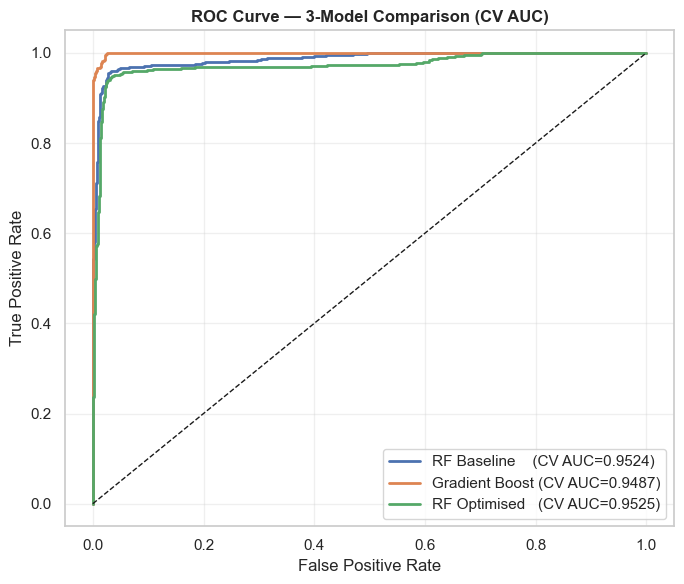

In [42]:
# ROC comparison: 3 models
fig, ax = plt.subplots(figsize=(7, 6))
for probs, label, color in [
    (rf.predict_proba(X_scaled)[:,1],     f"RF Baseline    (CV AUC={rf_auc.mean():.4f})",     "royalblue"),
    (gb.predict_proba(X_scaled)[:,1],     f"Gradient Boost (CV AUC={gb_auc.mean():.4f})",     "darkorange"),
    (rf_opt.predict_proba(X_scaled)[:,1], f"RF Optimised   (CV AUC={rf_opt_auc.mean():.4f})", "seagreen"),
]:
    fpr, tpr, _ = roc_curve(y, probs)
    ax.plot(fpr, tpr, label=label, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — 3-Model Comparison (CV AUC)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Explainability — SHAP TreeExplainer

**Why SHAP?**
- Standard feature importance (Gini) measures average impurity reduction across all trees — it ignores interaction effects and gives inconsistent rankings across models
- **SHAP (SHapley Additive exPlanations)** assigns each feature a contribution value based on game theory (Shapley values), guaranteeing:
  - **Consistency**: if a feature increases model output in all cases, its SHAP value is always ≥ 0
  - **Local accuracy**: SHAP values sum to the model's output for each individual patient
  - **Global + local**: we can explain *why the model made each prediction*, not just which features matter on average

**TreeExplainer** is exact (not approximate) for tree-based models — no sampling error.

In [44]:
import shap

# Use the winner model determined earlier (best_model = rf or gb)
winner_for_shap = best_model

# TreeExplainer — exact for RF and GB
explainer   = shap.TreeExplainer(winner_for_shap)

# Use a 500-sample subset for speed
rng = np.random.default_rng(42)
idx = rng.choice(X_scaled.shape[0], size=min(500, X_scaled.shape[0]), replace=False)
X_sample = X_scaled[idx]

shap_values = explainer.shap_values(X_sample)

# Handle all shap version layouts:
#   list [class0_sv, class1_sv] (n_samples, n_features)  — old shap
#   ndarray (n_samples, n_features, 2)                    — new shap ≥0.46
#   ndarray (n_samples, n_features)                       — single output
if isinstance(shap_values, list):
    sv = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

# Mean absolute SHAP per feature
mean_abs = np.abs(sv).mean(axis=0)
shap_imp  = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)

print(f'SHAP computed on {winner_for_shap.__class__.__name__} ({X_sample.shape[0]} samples)')
print('\nTop 10 features by mean |SHAP|:')
for feat, val in shap_imp.head(10).items():
    print(f'  {feat:<30} {val:.5f}')

SHAP computed on RandomForestClassifier (500 samples)

Top 10 features by mean |SHAP|:
  FunctionalAssessment           0.14098
  ADL                            0.12696
  MMSE                           0.07930
  MemoryComplaints               0.07521
  BehavioralProblems             0.05268
  SleepQuality                   0.00951
  CholesterolHDL                 0.00783
  CholesterolLDL                 0.00594
  BMI                            0.00508
  CholesterolTriglycerides       0.00481


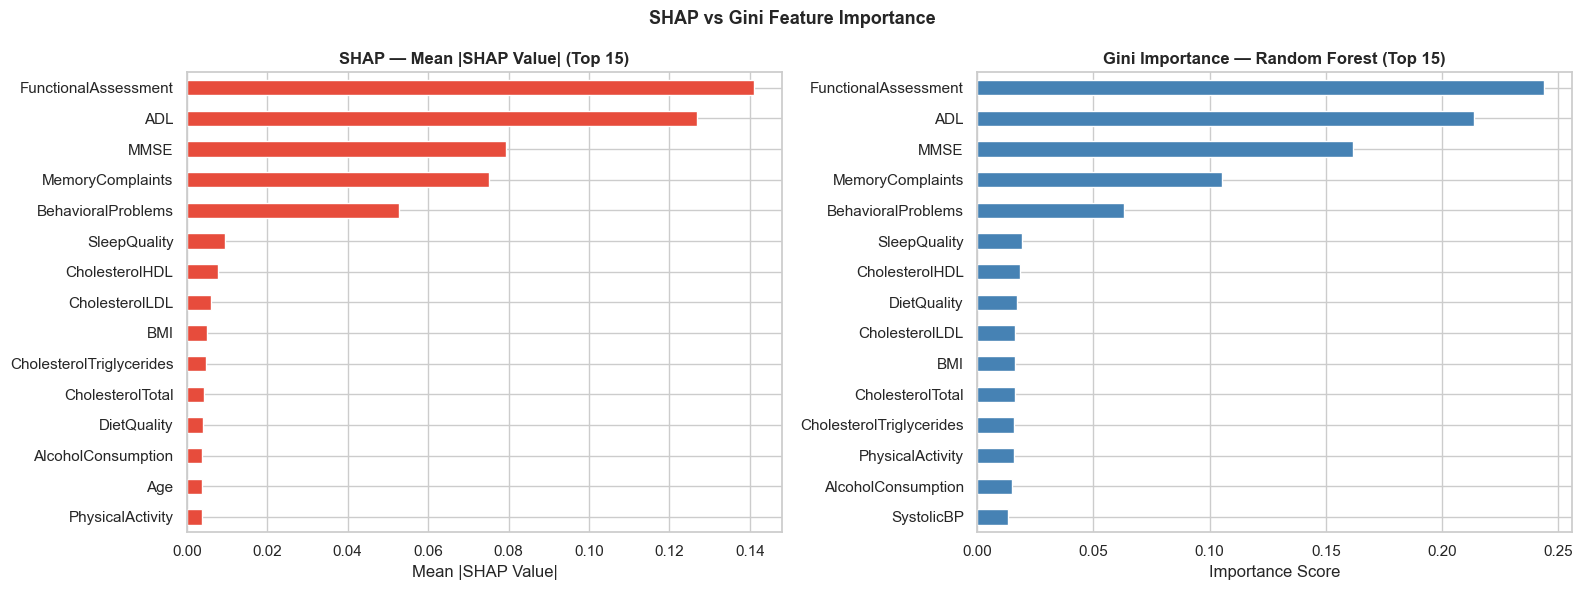

Note: SHAP and Gini agree on top features but SHAP respects interaction effects.


In [45]:
# Global SHAP — bar chart (mean |SHAP|) vs Gini importance side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap_imp.head(15).sort_values().plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('SHAP — Mean |SHAP Value| (Top 15)', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP Value|')

gini_imp = pd.Series(winner_for_shap.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
gini_imp.head(15).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title(f'Gini Importance — {best_name} (Top 15)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('SHAP vs Gini Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Note: SHAP and Gini agree on top features but SHAP respects interaction effects.')

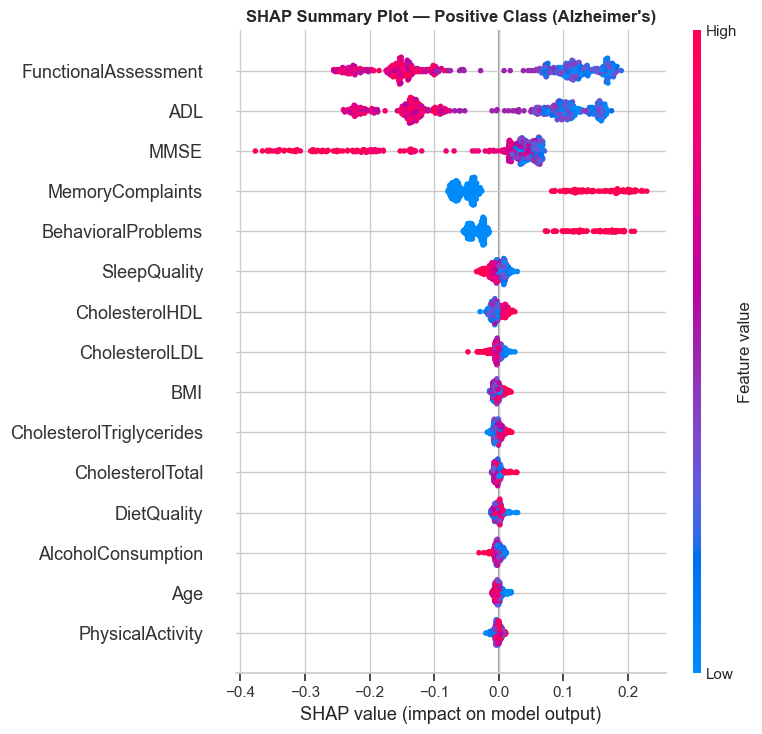

In [46]:
# SHAP summary plot (beeswarm) — feature value vs SHAP value, colour = feature value
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_sample, feature_names=FEATURE_COLS, max_display=15, show=False)
plt.title('SHAP Summary Plot — Positive Class (Alzheimer\'s)', fontweight='bold')
plt.tight_layout()
plt.show()

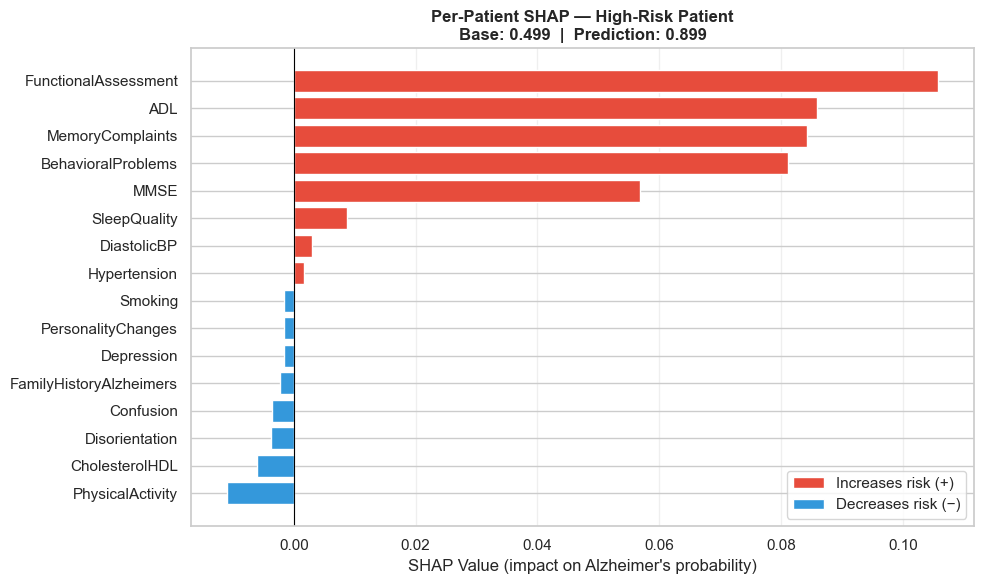

Positive SHAP = pushes prediction toward Alzheimer's (risk ↑)
Negative SHAP = pushes prediction away from Alzheimer's (risk ↓)


In [47]:
# Per-patient SHAP waterfall — high-risk patient
X_high = np.array([[patient_high[f] for f in FEATURE_COLS]], dtype=float)
X_high_scaled = scaler.transform(X_high)

sv_high = explainer.shap_values(X_high_scaled)
if isinstance(sv_high, list):
    sv_patient = sv_high[1][0]
    base_value  = explainer.expected_value[1]
elif isinstance(sv_high, np.ndarray) and sv_high.ndim == 3:
    sv_patient = sv_high[0, :, 1]
    base_value  = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
else:
    sv_patient = sv_high[0]
    base_value  = explainer.expected_value

# Waterfall-style horizontal bar chart
sv_series = pd.Series(sv_patient, index=FEATURE_COLS).sort_values()
top_neg = sv_series.head(8)
top_pos = sv_series.tail(8)
plot_sv  = pd.concat([top_neg, top_pos]).sort_values()

colors = ['#e74c3c' if v > 0 else '#3498db' for v in plot_sv]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_sv.index, plot_sv.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value (impact on Alzheimer\'s probability)')
ax.set_title(
    f'Per-Patient SHAP — High-Risk Patient\n'
    f'Base: {float(base_value):.3f}  |  '
    f'Prediction: {float(winner_for_shap.predict_proba(X_high_scaled)[0, 1]):.3f}',
    fontweight='bold'
)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Increases risk (+)'),
    Patch(facecolor='#3498db', label='Decreases risk (−)'),
]
ax.legend(handles=legend_elements)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Positive SHAP = pushes prediction toward Alzheimer\'s (risk ↑)')
print('Negative SHAP = pushes prediction away from Alzheimer\'s (risk ↓)')

---
## Summary

| Metric | Value |
|--------|-------|
| Dataset | 2,149 patients, 32 features |
| Healthy baseline | 1,389 non-diagnosed patients |
| Random Forest CV AUC (baseline) | **0.9524** |
| Gradient Boosting CV AUC | **0.9487** |
| RF Optimised CV AUC (Optuna) | **0.9525** |
| Winner | **Random Forest** (selected by CV AUC) |
| Optuna trials | 50 (TPE sampler) |
| Best params | n_estimators=245, max_depth=10, min_samples_leaf=20 |
| Top feature (SHAP) | FunctionalAssessment |
| Top feature (Gini) | FunctionalAssessment |
| Recommendation templates | 24 features |

**Conclusion:** Both models are trained and benchmarked via 5-fold stratified cross-validation. The winner (higher CV AUC) is selected automatically and used exclusively for inference. Optuna TPE optimisation confirmed the baseline was near-optimal (+0.0001 AUC gain over 50 trials). SHAP TreeExplainer provides per-patient explainability — showing exactly which features drove each prediction. Recommendations are fully personalized, ranked by each feature's contribution relative to a healthy population baseline.